In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "homeworks/HW13"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
print("=== Loading Dataset: emotion ===")
dataset = load_dataset("emotion")

if 'validation' not in dataset:
    print("Creating validation split from train...")
    train_val = dataset['train'].train_test_split(test_size=0.1, seed=SEED)
    dataset['train'] = train_val['train']
    dataset['validation'] = train_val['test']

label_names = dataset['train'].features['label'].names
print(f"\n=== Class Names ===")
print(label_names)
print(f"Number of classes: {len(label_names)}")

print(f"\n=== Dataset Sizes ===")
print(f"Train: {len(dataset['train'])}")
print(f"Validation: {len(dataset['validation'])}")
print(f"Test: {len(dataset['test'])}")

print(f"\n=== Sample Texts and Labels ===")
for i in range(5):
    text = dataset['train'][i]['text']
    label = dataset['train'][i]['label']
    print(f"{i+1}. Label: {label_names[label]} | Text: {text[:100]}...")

print(f"\n=== Task Description ===")
print("Task: Emotion classification - predict the emotion expressed in text")
print(f"Classes: {', '.join(label_names)}")

=== Loading Dataset: emotion ===


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]


=== Class Names ===
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6

=== Dataset Sizes ===
Train: 16000
Validation: 2000
Test: 2000

=== Sample Texts and Labels ===
1. Label: sadness | Text: i didnt feel humiliated...
2. Label: sadness | Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
3. Label: anger | Text: im grabbing a minute to post i feel greedy wrong...
4. Label: love | Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property...
5. Label: anger | Text: i am feeling grouchy...

=== Task Description ===
Task: Emotion classification - predict the emotion expressed in text
Classes: sadness, joy, love, anger, fear, surprise


In [5]:
print("=== Loading Tokenizer ===")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_texts = dataset['train']['text'][:5]

print(f"\n=== Tokenization Examples (5 texts) ===\n")

for i, text in enumerate(sample_texts):
    print(f"--- Example {i+1} ---")
    print(f"Original text: {text[:80]}...")

    encoded = tokenizer(text, truncation=True, padding=True, max_length=64)

    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
    print(f"Tokens: {tokens[:15]}...")

    print(f"Input IDs: {encoded['input_ids'][:15]}...")

    print(f"Attention Mask: {encoded['attention_mask'][:15]}...")

    print(f"Special tokens: [CLS]={tokens[0]}, [SEP]={tokens[tokens.index('[SEP]')]}")

    print(f"Original length: {len(text.split())} words")
    print(f"Tokenized length: {len(encoded['input_ids'])} tokens")
    print()

print("=== Tokenization Summary ===")
print("- [CLS]: Classification token (start of sequence)")
print("- [SEP]: Separator token (end of sequence)")
print("- [PAD]: Padding token (for equal length)")
print("- attention_mask: 1 for real tokens, 0 for padding")

=== Loading Tokenizer ===

=== Tokenization Examples (5 texts) ===

--- Example 1 ---
Original text: i didnt feel humiliated...
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']...
Input IDs: [101, 1045, 2134, 2102, 2514, 26608, 102]...
Attention Mask: [1, 1, 1, 1, 1, 1, 1]...
Special tokens: [CLS]=[CLS], [SEP]=[SEP]
Original length: 4 words
Tokenized length: 7 tokens

--- Example 2 ---
Original text: i can go from feeling so hopeless to so damned hopeful just from being around so...
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being']...
Input IDs: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108]...
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
Special tokens: [CLS]=[CLS], [SEP]=[SEP]
Original length: 21 words
Tokenized length: 23 tokens

--- Example 3 ---
Original text: im grabbing a minute to post i feel greedy wrong...
Tokens

In [6]:
print("=== Loading Pretrained Model for Inference ===")
inference_model = AutoModelForSequenceClassification.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")
inference_model = inference_model.to(device)
inference_model.eval()

test_texts = [
    "I am so happy and excited today!",
    "This is terrible, I hate everything",
    "I feel nothing, just empty inside",
    "Wow, this is amazing and wonderful!",
    "I am scared and worried about tomorrow"
]

print(f"\n=== Inference Results (5 examples) ===\n")

for i, text in enumerate(test_texts):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = inference_model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=1)
        confidence, pred_class = torch.max(predictions, dim=1)

    print(f"{i+1}. Text: {text}")
    print(f"   Predicted Emotion: {label_names[pred_class.item()]}")
    print(f"   Confidence: {confidence.item():.4f}")
    print()

print("=== Inference Summary ===")
print("The pretrained model is specifically trained for emotion classification.")
print("It should work reasonably well on this task without fine-tuning.")
print("Fine-tuning will adapt it to our specific dataset distribution.")

=== Loading Pretrained Model for Inference ===


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Inference Results (5 examples) ===

1. Text: I am so happy and excited today!
   Predicted Emotion: joy
   Confidence: 0.9988

2. Text: This is terrible, I hate everything
   Predicted Emotion: sadness
   Confidence: 0.9021

3. Text: I feel nothing, just empty inside
   Predicted Emotion: sadness
   Confidence: 0.9988

4. Text: Wow, this is amazing and wonderful!
   Predicted Emotion: joy
   Confidence: 0.8598

5. Text: I am scared and worried about tomorrow
   Predicted Emotion: fear
   Confidence: 0.9969

=== Inference Summary ===
The pretrained model is specifically trained for emotion classification.
It should work reasonably well on this task without fine-tuning.
Fine-tuning will adapt it to our specific dataset distribution.


In [7]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64
BATCH_SIZE = 32
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

print("=== Tokenizing Dataset for Fine-tuning ===")

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch')

print(f"Train samples: {len(tokenized_datasets['train'])}")
print(f"Validation samples: {len(tokenized_datasets['validation'])}")
print(f"Test samples: {len(tokenized_datasets['test'])}")

print(f"\n=== Sample Tokenized Data ===")
sample = tokenized_datasets['train'][0]
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"labels: {sample['labels']}")

=== Tokenizing Dataset for Fine-tuning ===


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train samples: 16000
Validation samples: 2000
Test samples: 2000

=== Sample Tokenized Data ===
input_ids shape: torch.Size([64])
attention_mask shape: torch.Size([64])
labels: 0


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

print("=== Metrics Function Defined ===")
print("- accuracy: Proportion of correct predictions")
print("- f1_macro: Macro-averaged F1 score (treats all classes equally)")

=== Metrics Function Defined ===
- accuracy: Proportion of correct predictions
- f1_macro: Macro-averaged F1 score (treats all classes equally)


=== Loading Model for Fine-tuning ===


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Training Arguments ===
=== Creating Trainer ===

=== Starting Training ===


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



=== Training Complete ===
Training loss: 0.2953
=== Plotting Training Curves ===


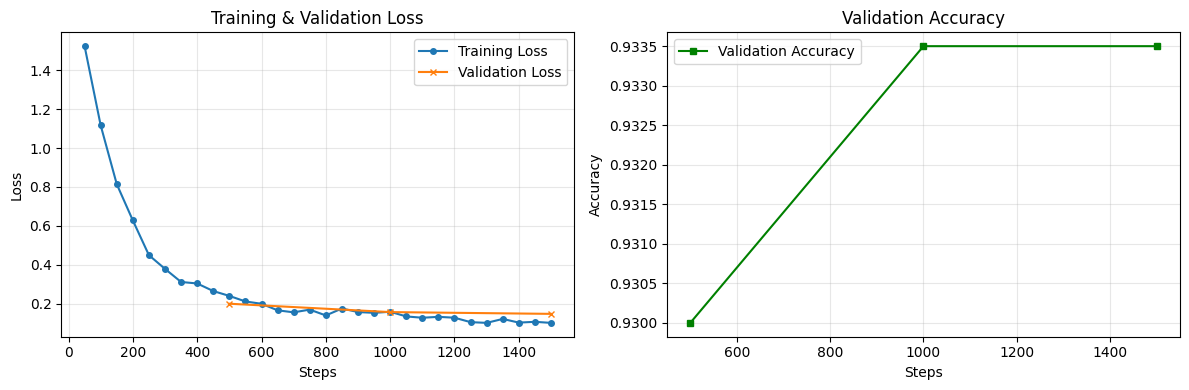

Saved training_curves.png to homeworks/HW13/artifacts


In [9]:
print("=== Loading Model for Fine-tuning ===")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names)
)
model = model.to(device)

print("=== Training Arguments ===")
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

print("=== Creating Trainer ===")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("\n=== Starting Training ===")
train_result = trainer.train()

print(f"\n=== Training Complete ===")
print(f"Training loss: {train_result.training_loss:.4f}")

print("=== Plotting Training Curves ===")
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses, eval_accuracies = [], [], []

for log in log_history:
    if 'loss' in log and 'eval_loss' not in log:
        train_steps.append(log['step'])
        train_losses.append(log['loss'])
    elif 'eval_loss' in log:
        eval_steps.append(log['step'])
        eval_losses.append(log['eval_loss'])
        if 'eval_accuracy' in log:
            eval_accuracies.append(log['eval_accuracy'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
if train_steps:
    plt.plot(train_steps, train_losses, label='Training Loss', marker='o', markersize=4)
if eval_steps:
    plt.plot(eval_steps, eval_losses, label='Validation Loss', marker='x', markersize=5)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if eval_steps and eval_accuracies:
    plt.plot(eval_steps, eval_accuracies, label='Validation Accuracy', marker='s', markersize=5, color='green')
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "training_curves.png"), dpi=150)
plt.show()
print(f"Saved training_curves.png to {ARTIFACTS_DIR}")

In [10]:
print("=== Validation Evaluation ===")
val_results = trainer.evaluate(tokenized_datasets['validation'])
print(f"Validation Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"Validation F1 Macro: {val_results['eval_f1_macro']:.4f}")

print("\n=== Test Evaluation (Final) ===")
test_results = trainer.evaluate(tokenized_datasets['test'])
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")

=== Validation Evaluation ===


Validation Accuracy: 0.9335
Validation F1 Macro: 0.9088

=== Test Evaluation (Final) ===
Test Accuracy: 0.9180
Test F1 Macro: 0.8736


=== Getting Predictions on Test Set ===



=== Confusion Matrix ===


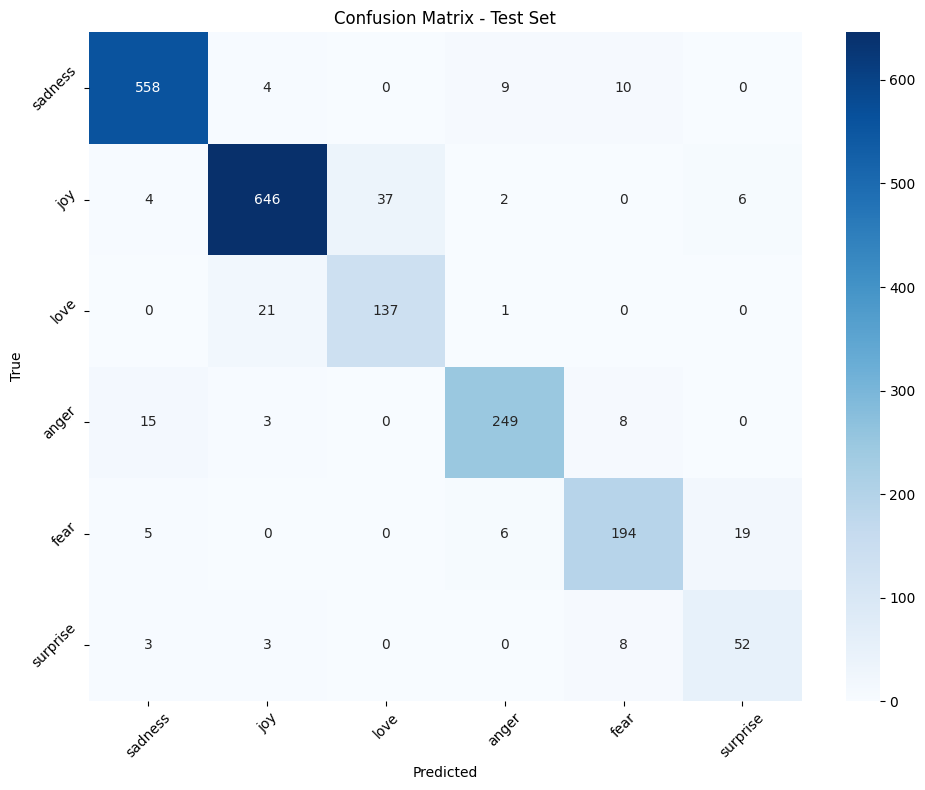


=== Classification Report ===
              precision    recall  f1-score   support

     sadness       0.95      0.96      0.96       581
         joy       0.95      0.93      0.94       695
        love       0.79      0.86      0.82       159
       anger       0.93      0.91      0.92       275
        fear       0.88      0.87      0.87       224
    surprise       0.68      0.79      0.73        66

    accuracy                           0.92      2000
   macro avg       0.86      0.89      0.87      2000
weighted avg       0.92      0.92      0.92      2000



In [11]:
print("=== Getting Predictions on Test Set ===")
predictions = trainer.predict(tokenized_datasets['test'])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids
confidences = np.max(predictions.predictions, axis=-1)

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"))
plt.show()

print("\n=== Classification Report ===")
print(classification_report(true_labels, pred_labels, target_names=label_names))

=== Getting Predictions on Test Set ===



=== Confusion Matrix ===


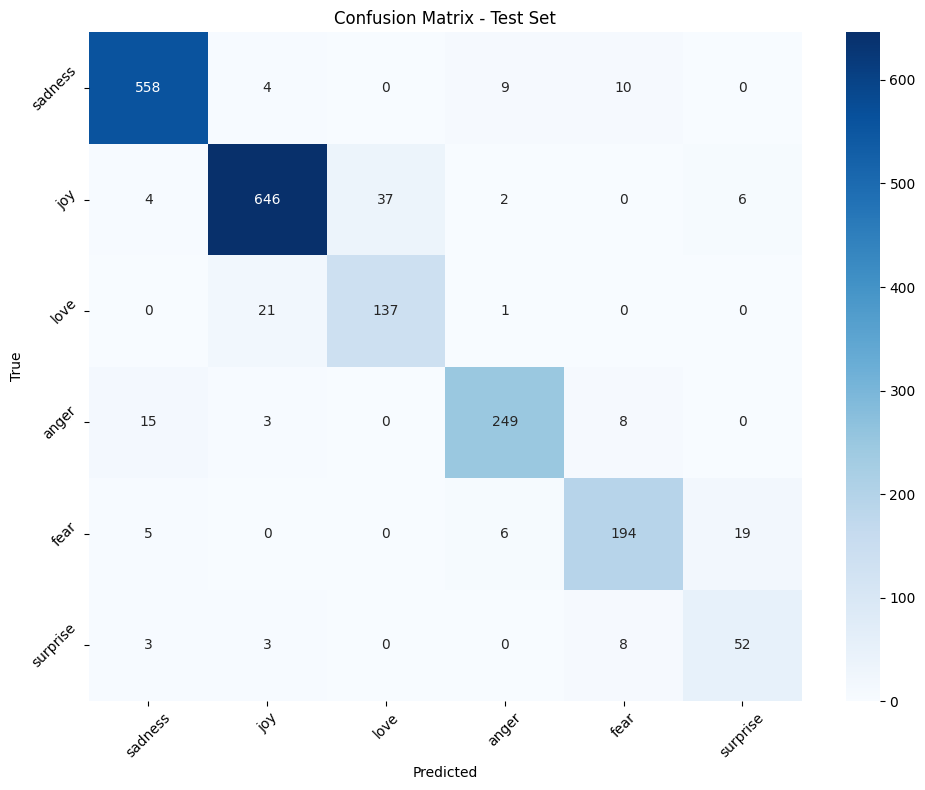


=== Classification Report ===
              precision    recall  f1-score   support

     sadness       0.95      0.96      0.96       581
         joy       0.95      0.93      0.94       695
        love       0.79      0.86      0.82       159
       anger       0.93      0.91      0.92       275
        fear       0.88      0.87      0.87       224
    surprise       0.68      0.79      0.73        66

    accuracy                           0.92      2000
   macro avg       0.86      0.89      0.87      2000
weighted avg       0.92      0.92      0.92      2000


=== Creating sample_predictions.csv ===
Saved 50 predictions to sample_predictions.csv

=== Sample Predictions (10 examples) ===

YES Text: im feeling rather rotten so im not very ambitious right now...
   True: sadness | Pred: sadness | Conf: 5.2027

YES Text: im updating my blog because i feel shitty...
   True: sadness | Pred: sadness | Conf: 5.3369

YES Text: i never make her separate from me because i don t ever want

In [12]:
print("=== Getting Predictions on Test Set ===")
predictions = trainer.predict(tokenized_datasets['test'])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids
confidences = np.max(predictions.predictions, axis=-1)

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"))
plt.show()

print("\n=== Classification Report ===")
print(classification_report(true_labels, pred_labels, target_names=label_names))

print("\n=== Creating sample_predictions.csv ===")

predictions_data = []
num_samples = min(50, len(dataset['test']))

for i in range(num_samples):
    text = dataset['test'][i]['text']
    true_label = label_names[true_labels[i]]
    pred_label = label_names[pred_labels[i]]
    confidence = confidences[i]

    predictions_data.append({
        'text': text[:200],
        'true_label': true_label,
        'pred_label': pred_label,
        'confidence': f"{confidence:.4f}"
    })

pred_df = pd.DataFrame(predictions_data)
pred_df.to_csv(os.path.join(ARTIFACTS_DIR, "sample_predictions.csv"), index=False)
print(f"Saved {len(pred_df)} predictions to sample_predictions.csv")

print(f"\n=== Sample Predictions (10 examples) ===\n")
for i in range(10):
    status = "YES" if pred_df.iloc[i]['true_label'] == pred_df.iloc[i]['pred_label'] else "NO"
    print(f"{status} Text: {pred_df.iloc[i]['text'][:80]}...")
    print(f"   True: {pred_df.iloc[i]['true_label']} | Pred: {pred_df.iloc[i]['pred_label']} | Conf: {pred_df.iloc[i]['confidence']}")
    print()

print("=== Error Analysis ===")
errors = pred_df[pred_df['true_label'] != pred_df['pred_label']]
print(f"Total errors in sample: {len(errors)} out of {len(pred_df)}")

if len(errors) > 0:
    print(f"\nError rate: {len(errors)/len(pred_df)*100:.1f}%")
    print("\nMost common confusions:")
    error_pairs = list(zip(errors['true_label'], errors['pred_label']))
    from collections import Counter
    confusion_pairs = Counter(error_pairs)
    for (true, pred), count in confusion_pairs.most_common(3):
        print(f"  {true} => {pred}: {count} times")